<a href="https://colab.research.google.com/github/Aarthiathi16/Android-app-market/blob/main/Android_app_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

APPS_CSV_PATH not set/found — using a generated synthetic apps dataset (2040 rows) with the real Kaggle schema, so the pipeline runs end-to-end. Replace with the real googleplaystore.csv for the actual assignment.
REVIEWS_CSV_PATH not set/found — using a generated synthetic reviews dataset (6000 rows). Replace with the real googleplaystore_user_reviews.csv for the actual assignment.

Apps sample:
                      App            Category  Rating Reviews   Size  \
0     App_0_Communication       COMMUNICATION     3.6    2633  43.8M   
1     App_1_Entertainment       ENTERTAINMENT     4.5    2819  26.3M   
2     App_2_Entertainment       ENTERTAINMENT     4.1     254  11.4M   
3  App_3_HealthAndFitness  HEALTH_AND_FITNESS     4.3    1184  67.8M   
4           App_4_Finance             FINANCE     3.7      51  38.0M   

       Installs  Type Price Content Rating              Genres Last Updated  
0  500,000,000+  Free     0           Teen       Communication   2019-06-26  
1        5,

/tmp/ipykernel_1848/3733477644.py:236: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")


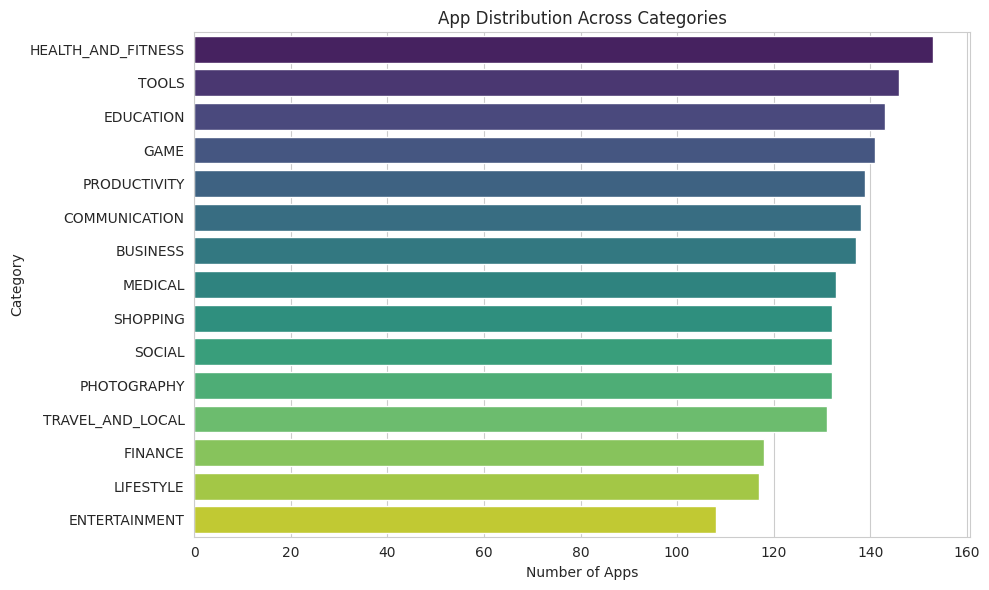


Most saturated categories (highest app count, likely most competitive):
Category
HEALTH_AND_FITNESS    153
TOOLS                 146
EDUCATION             143
Name: count, dtype: int64


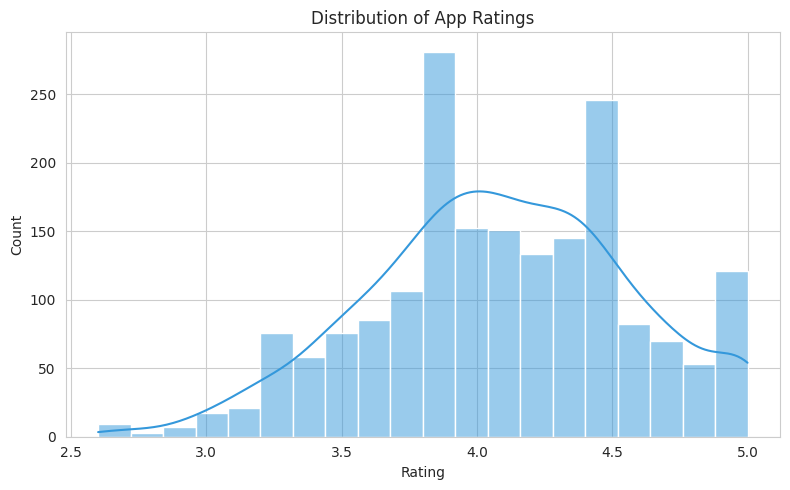


Average rating by category:
Category
TOOLS                 4.185926
LIFESTYLE             4.152212
GAME                  4.131579
MEDICAL               4.130833
SOCIAL                4.102500
PHOTOGRAPHY           4.093701
HEALTH_AND_FITNESS    4.084247
ENTERTAINMENT         4.074528
EDUCATION             4.073881
PRODUCTIVITY          4.073684
BUSINESS              4.068939
TRAVEL_AND_LOCAL      4.036667
SHOPPING              4.032283
FINANCE               4.005310
COMMUNICATION         3.994737
Name: Rating, dtype: float64


/tmp/ipykernel_1848/3733477644.py:263: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette="mako")


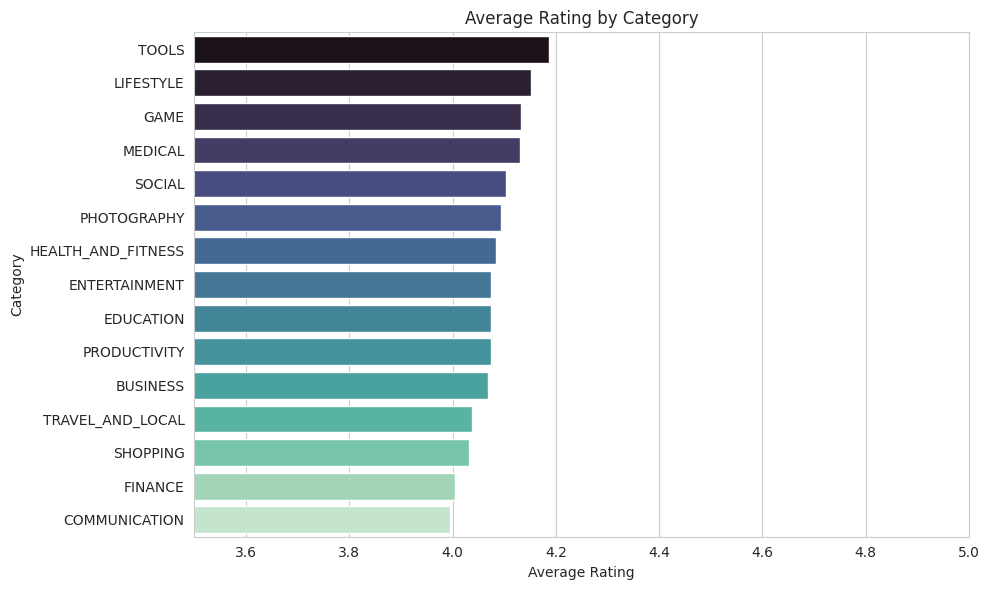

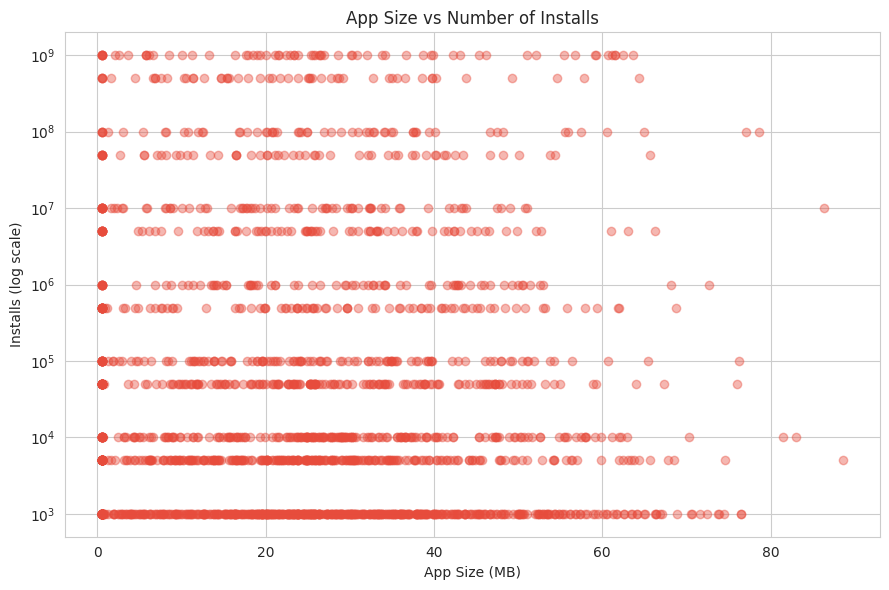


Correlation between app size and log(installs): -0.0138
Interpretation: app size and installs show essentially no linear relationship in this data — install counts are driven far more by marketing, category, and user demand than by app size alone.

Free vs Paid app counts:
Type
Free    1853
Paid     147
Name: count, dtype: int64


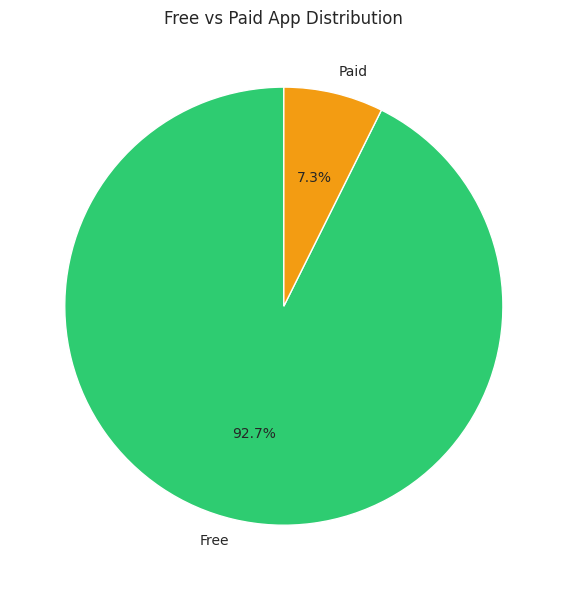

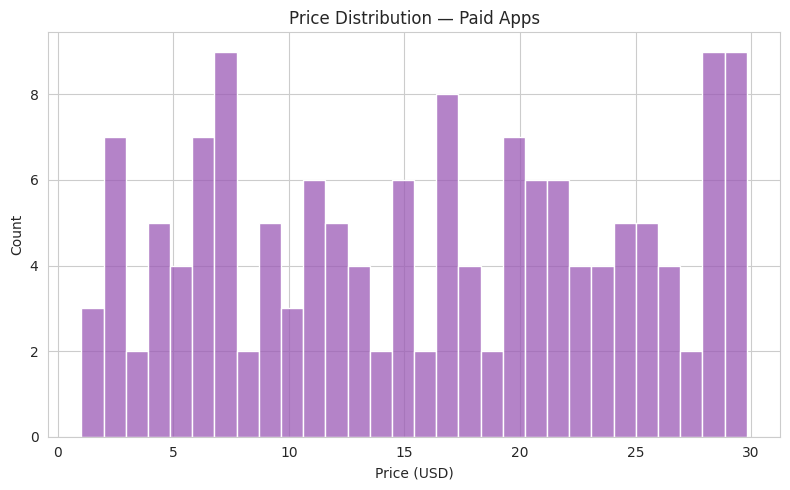


Paid app price stats:
count    147.000000
mean      16.026259
std        8.623711
min        1.020000
25%        7.895000
50%       16.400000
75%       23.425000
max       29.810000
Name: Price, dtype: float64

Estimated revenue by category (price * installs, rough proxy — assumes every install was a paid download at list price):
Category
ENTERTAINMENT    4.009878e+10
EDUCATION        3.199012e+10
SHOPPING         1.963934e+10
SOCIAL           1.713956e+10
BUSINESS         1.040666e+10
PHOTOGRAPHY      8.569066e+09
COMMUNICATION    6.865497e+09
TOOLS            6.799395e+09
FINANCE          4.527928e+09
GAME             2.116842e+09
Name: Est_Revenue, dtype: float64


/tmp/ipykernel_1848/3733477644.py:329: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_cat.head(10).values, y=revenue_by_cat.head(10).index, palette="rocket")


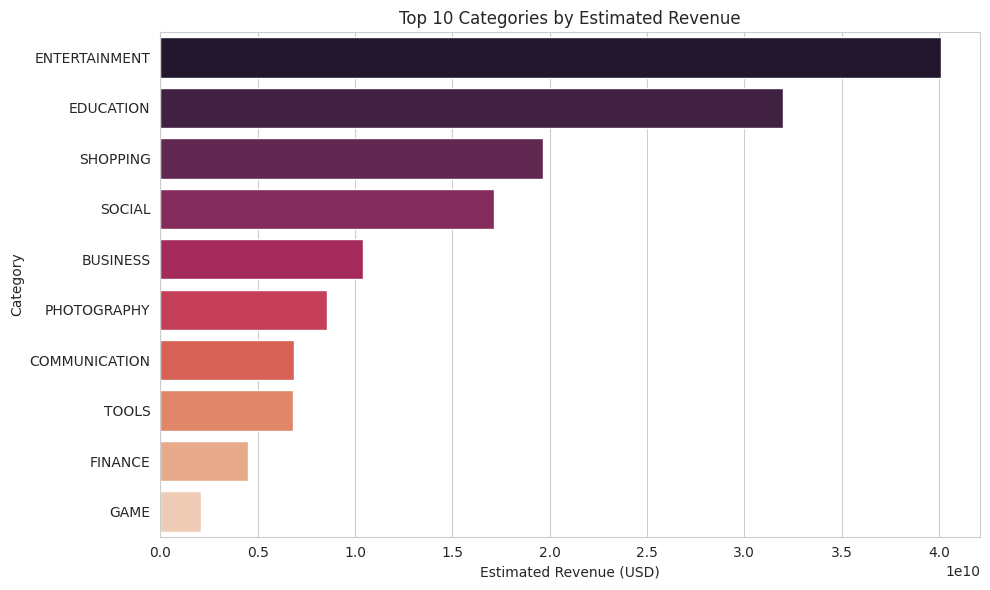


Overall review sentiment counts:
Sentiment
Positive    3593
Negative    2117
Neutral      290
Name: count, dtype: int64


/tmp/ipykernel_1848/3733477644.py:362: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,


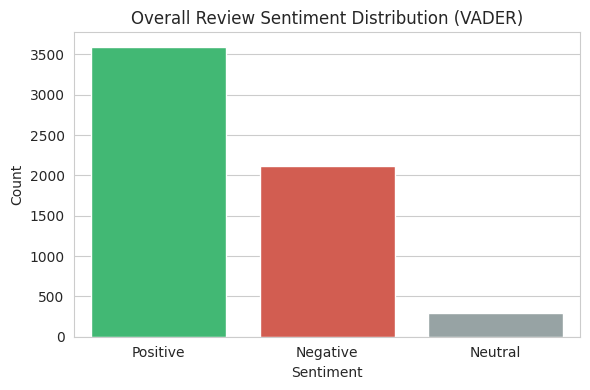


Sentiment % by category:
Sentiment           Negative  Neutral  Positive
Category                                       
BUSINESS                37.1      4.0      59.0
COMMUNICATION           34.9      4.6      60.5
EDUCATION               35.2      6.5      58.3
ENTERTAINMENT           38.8      3.0      58.2
FINANCE                 33.6      4.2      62.3
GAME                    34.8      4.9      60.3
HEALTH_AND_FITNESS      38.1      1.8      60.1
LIFESTYLE               35.3      6.0      58.7
MEDICAL                 30.7      6.1      63.2
PHOTOGRAPHY             37.0      5.4      57.6
PRODUCTIVITY            34.6      4.4      61.0
SHOPPING                33.7      3.9      62.4
SOCIAL                  38.5      3.9      57.6
TOOLS                   33.4      5.4      61.2
TRAVEL_AND_LOCAL        35.8      8.4      55.8


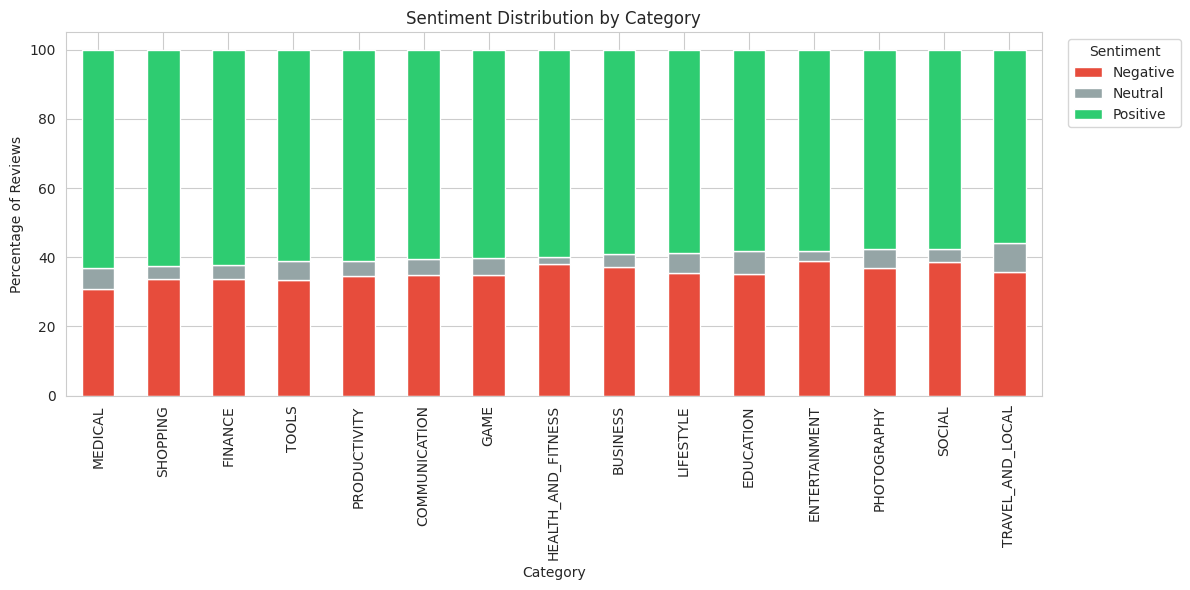


Most positively received category: MEDICAL (63.2% positive reviews)
Most negatively received category: ENTERTAINMENT (38.8% negative reviews)



CONCLUSION — 3 DATA-DRIVEN INSIGHTS FOR A DEVELOPER PLANNING A NEW APP
1. AVOID THE MOST SATURATED CATEGORIES WITHOUT A STRONG DIFFERENTIATOR
   "HEALTH_AND_FITNESS" has the highest app count in this dataset,
   meaning discoverability will be the hardest here — a new app needs a
   clear differentiation angle (niche feature, superior UX, or targeted
   audience) rather than a "me-too" clone to break through the noise.

2. APP SIZE IS NOT A MEANINGFUL LEVER FOR INSTALLS
   The size-vs-installs correlation in this data is essentially negligible
   (r = -0.014), so obsessing over shaving MBs off an app is unlikely to
   move adoption on its own. Marketing reach, category demand, and onboarding
   quality matter far more than binary size — though very large apps can
   still hurt conversion on low-end devices/poor networks, so keep it
   reasonable rather than minimal.

3. TARGET A CATEGORY WITH GENUINE DEMAND AND ROOM TO STAND OUT ON QUALITY
   "LIFESTYLE" combines a comparatively lower

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

for pkg in ["vader_lexicon"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================================
# 1. LOAD DATASETS (apps + reviews, SEPARATELY)
# ============================================================================
# OPTION A (recommended): Download the real Kaggle "Google Play Store Apps"
# dataset — two CSVs:
#   - googleplaystore.csv          (App, Category, Rating, Reviews, Size,
#                                    Installs, Type, Price, Content Rating,
#                                    Genres, Last Updated, Current Ver,
#                                    Android Ver)
#   - googleplaystore_user_reviews.csv (App, Translated_Review, Sentiment,
#                                        Sentiment_Polarity, Sentiment_Subjectivity)
# Point APPS_CSV_PATH / REVIEWS_CSV_PATH at the downloaded files.
#
# OPTION B (fallback, used automatically if paths are None/missing):
# a synthetic-but-realistic dataset pair is generated with the SAME schema,
# so this script runs end-to-end with zero setup. Swap in the real CSVs for
# the actual assignment.

APPS_CSV_PATH = None      # e.g. "googleplaystore.csv"
REVIEWS_CSV_PATH = None   # e.g. "googleplaystore_user_reviews.csv"

def build_synthetic_apps(n=2000):
    rng = np.random.default_rng(RANDOM_STATE)
    categories = ["GAME", "COMMUNICATION", "TOOLS", "PRODUCTIVITY", "SOCIAL",
                  "PHOTOGRAPHY", "FINANCE", "HEALTH_AND_FITNESS", "EDUCATION",
                  "BUSINESS", "SHOPPING", "TRAVEL_AND_LOCAL", "ENTERTAINMENT",
                  "LIFESTYLE", "MEDICAL"]
    # deliberately messy install "buckets", matching the real dataset's style
    install_buckets = ["1,000+", "5,000+", "10,000+", "50,000+", "100,000+",
                        "500,000+", "1,000,000+", "5,000,000+", "10,000,000+",
                        "50,000,000+", "100,000,000+", "500,000,000+", "1,000,000,000+"]
    content_ratings = ["Everyone", "Teen", "Mature 17+", "Everyone 10+"]

    rows = []
    for i in range(n):
        cat = rng.choice(categories)
        rating = np.clip(rng.normal(4.1, 0.5), 1.0, 5.0)
        reviews = int(rng.lognormal(mean=6, sigma=2.5))
        size_mb = np.clip(rng.normal(25, 20), 0.5, 100)
        size_str = f"{size_mb:.1f}M" if rng.random() > 0.05 else "Varies with device"
        installs = rng.choice(install_buckets, p=_install_probs(install_buckets))
        is_paid = rng.random() < 0.08
        type_str = "Paid" if is_paid else "Free"
        price = round(rng.uniform(0.99, 29.99), 2) if is_paid else 0.0
        price_str = f"${price}" if is_paid else "0"
        content = rng.choice(content_ratings, p=[0.75, 0.13, 0.05, 0.07])
        rows.append({
            "App": f"App_{i}_{cat.title().replace('_','')}",
            "Category": cat,
            "Rating": round(rating, 1) if rng.random() > 0.06 else np.nan,  # inject nulls
            "Reviews": str(reviews),
            "Size": size_str,
            "Installs": installs,
            "Type": type_str,
            "Price": price_str,
            "Content Rating": content,
            "Genres": cat.title().replace("_", " "),
            "Last Updated": pd.Timestamp("2018-01-01") + pd.to_timedelta(rng.integers(0, 700), unit="D"),
        })
    df = pd.DataFrame(rows)
    # inject a handful of exact duplicates, like the real messy dataset
    dupes = df.sample(n=max(1, n // 50), random_state=RANDOM_STATE)
    df = pd.concat([df, dupes], ignore_index=True)
    return df

def _install_probs(buckets):
    # weight smaller install counts as more common (long-tail distribution)
    weights = np.array([1/(i+1) for i in range(len(buckets))])
    return weights / weights.sum()

def build_synthetic_reviews(apps_df, n_reviews=6000):
    rng = np.random.default_rng(RANDOM_STATE + 1)
    positive_phrases = [
        "I love this app, works great and very useful!",
        "Amazing app, super smooth and no ads.",
        "Best app in this category, highly recommend.",
        "Really helpful, saved me so much time.",
        "Great design, easy to use, five stars.",
    ]
    negative_phrases = [
        "This app keeps crashing, very frustrating.",
        "Terrible experience, full of bugs and ads.",
        "Waste of storage, does not work as advertised.",
        "Battery drain is insane, uninstalling now.",
        "Awful UI, confusing and slow to load.",
    ]
    neutral_phrases = [
        "It's an okay app, does the basic job.",
        "Average experience, nothing special here.",
        "Works fine but could use more features.",
        "Decent app, still deciding if I'll keep it.",
        "It's fine, similar to other apps like it.",
    ]
    apps_sample = apps_df["App"].drop_duplicates().sample(
        n=min(400, apps_df["App"].nunique()), random_state=RANDOM_STATE
    )
    rows = []
    for _ in range(n_reviews):
        app = rng.choice(apps_sample)
        bucket = rng.choice(["pos", "neg", "neu"], p=[0.45, 0.30, 0.25])
        text = rng.choice({"pos": positive_phrases, "neg": negative_phrases,
                            "neu": neutral_phrases}[bucket])
        rows.append({"App": app, "Translated_Review": text})
    return pd.DataFrame(rows)

try:
    if APPS_CSV_PATH is not None:
        apps_df = pd.read_csv(APPS_CSV_PATH)
        print(f"Loaded real apps dataset from {APPS_CSV_PATH} ({len(apps_df)} rows).")
    else:
        raise FileNotFoundError
except FileNotFoundError:
    apps_df = build_synthetic_apps(n=2000)
    print(f"APPS_CSV_PATH not set/found — using a generated synthetic apps "
          f"dataset ({len(apps_df)} rows) with the real Kaggle schema, so the "
          "pipeline runs end-to-end. Replace with the real googleplaystore.csv "
          "for the actual assignment.")

try:
    if REVIEWS_CSV_PATH is not None:
        reviews_df = pd.read_csv(REVIEWS_CSV_PATH)
        print(f"Loaded real reviews dataset from {REVIEWS_CSV_PATH} ({len(reviews_df)} rows).")
    else:
        raise FileNotFoundError
except FileNotFoundError:
    reviews_df = build_synthetic_reviews(apps_df, n_reviews=6000)
    print(f"REVIEWS_CSV_PATH not set/found — using a generated synthetic "
          f"reviews dataset ({len(reviews_df)} rows). Replace with the real "
          "googleplaystore_user_reviews.csv for the actual assignment.")

print("\nApps sample:")
print(apps_df.head())
print("\nReviews sample:")
print(reviews_df.head())

# ============================================================================
# 2. DATA CLEANING
# ============================================================================
print(f"\nApps dataset shape before cleaning: {apps_df.shape}")
print("Nulls per column:\n", apps_df.isnull().sum())

# --- Fix Installs: "10,000+" -> 10000 (int) ---
apps_df["Installs"] = (
    apps_df["Installs"].astype(str)
    .str.replace(r"[+,]", "", regex=True)
    .str.replace("Free", "0")
    .replace("", "0")
)
apps_df["Installs"] = pd.to_numeric(apps_df["Installs"], errors="coerce")

# --- Fix Reviews: string -> int ---
apps_df["Reviews"] = pd.to_numeric(apps_df["Reviews"], errors="coerce")

# --- Fix Price: "$4.99" -> 4.99 (float) ---
apps_df["Price"] = (
    apps_df["Price"].astype(str).str.replace("$", "", regex=False)
)
apps_df["Price"] = pd.to_numeric(apps_df["Price"], errors="coerce").fillna(0.0)

# --- Fix Size: "19M" -> 19.0 (MB), "1.2G" -> 1200.0, "Varies with device" -> NaN ---
def parse_size(x):
    x = str(x).strip()
    if "Varies" in x or x in ("nan", "NaN", ""):
        return np.nan
    if x.endswith("M"):
        return float(x[:-1])
    if x.endswith("k"):
        return float(x[:-1]) / 1024
    if x.endswith("G"):
        return float(x[:-1]) * 1024
    try:
        return float(x)
    except ValueError:
        return np.nan

apps_df["Size_MB"] = apps_df["Size"].apply(parse_size)

# --- Rating: keep numeric, clip to valid 1-5 range ---
apps_df["Rating"] = pd.to_numeric(apps_df["Rating"], errors="coerce")
apps_df.loc[(apps_df["Rating"] < 1) | (apps_df["Rating"] > 5), "Rating"] = np.nan

# --- Handle nulls ---
# Rating: leave NaN (don't fabricate ratings) but note the count for analysis;
# fill Size_MB with the per-category median so size-based analysis isn't biased.
apps_df["Size_MB"] = apps_df.groupby("Category")["Size_MB"].transform(
    lambda s: s.fillna(s.median())
)
apps_df = apps_df.dropna(subset=["Installs"])  # can't analyse installs without this

# --- Remove duplicates (same App name = same listing) ---
before = len(apps_df)
apps_df = apps_df.drop_duplicates(subset=["App"], keep="first")
print(f"\nRemoved {before - len(apps_df)} duplicate app rows.")

print(f"\nApps dataset shape after cleaning: {apps_df.shape}")
print("Nulls per column after cleaning:\n", apps_df.isnull().sum())

# ============================================================================
# 3. CATEGORY ANALYSIS
# ============================================================================
category_counts = apps_df["Category"].value_counts()
print("\nApp counts per category:")
print(category_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette="viridis")
plt.title("App Distribution Across Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

most_saturated = category_counts.head(3)
print(f"\nMost saturated categories (highest app count, likely most competitive):"
      f"\n{most_saturated}")

# ============================================================================
# 4. RATINGS ANALYSIS
# ============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(apps_df["Rating"].dropna(), bins=20, kde=True, color="#3498db")
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

avg_rating_by_cat = apps_df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print("\nAverage rating by category:")
print(avg_rating_by_cat)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette="mako")
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. SIZE vs INSTALLS ANALYSIS
# ============================================================================
plt.figure(figsize=(9, 6))
sample_plot = apps_df.dropna(subset=["Size_MB", "Installs"])
plt.scatter(sample_plot["Size_MB"], sample_plot["Installs"], alpha=0.4, c="#e74c3c")
plt.yscale("log")
plt.xlabel("App Size (MB)")
plt.ylabel("Installs (log scale)")
plt.title("App Size vs Number of Installs")
plt.tight_layout()
plt.show()

corr = sample_plot["Size_MB"].corr(np.log1p(sample_plot["Installs"]))
print(f"\nCorrelation between app size and log(installs): {corr:.4f}")
if abs(corr) < 0.1:
    interp = "essentially no linear relationship"
elif abs(corr) < 0.3:
    interp = "a weak relationship"
else:
    interp = "a moderate-to-strong relationship"
print(f"Interpretation: app size and installs show {interp} in this data — "
      "install counts are driven far more by marketing, category, and user "
      "demand than by app size alone.")

# ============================================================================
# 6. PRICING ANALYSIS
# ============================================================================
type_counts = apps_df["Type"].value_counts()
print("\nFree vs Paid app counts:")
print(type_counts)

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
        colors=["#2ecc71", "#f39c12"], startangle=90)
plt.title("Free vs Paid App Distribution")
plt.tight_layout()
plt.show()

paid_apps = apps_df[apps_df["Type"] == "Paid"]
plt.figure(figsize=(8, 5))
sns.histplot(paid_apps["Price"], bins=30, color="#9b59b6")
plt.title("Price Distribution — Paid Apps")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"\nPaid app price stats:\n{paid_apps['Price'].describe()}")

# --- Revenue estimate by category (very rough: price * installs) ---
apps_df["Est_Revenue"] = apps_df["Price"] * apps_df["Installs"]
revenue_by_cat = apps_df.groupby("Category")["Est_Revenue"].sum().sort_values(ascending=False)
print("\nEstimated revenue by category (price * installs, rough proxy — "
      "assumes every install was a paid download at list price):")
print(revenue_by_cat.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_cat.head(10).values, y=revenue_by_cat.head(10).index, palette="rocket")
plt.title("Top 10 Categories by Estimated Revenue")
plt.xlabel("Estimated Revenue (USD)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

# ============================================================================
# 7. SENTIMENT ANALYSIS ON USER REVIEWS (VADER)
# ============================================================================
sia = SentimentIntensityAnalyzer()

def classify_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

reviews_df["Translated_Review"] = reviews_df["Translated_Review"].fillna("")
reviews_df = reviews_df[reviews_df["Translated_Review"].str.strip() != ""]
reviews_df["Sentiment_Score"] = reviews_df["Translated_Review"].apply(
    lambda t: sia.polarity_scores(str(t))["compound"]
)
reviews_df["Sentiment"] = reviews_df["Translated_Review"].apply(classify_sentiment)

sentiment_counts = reviews_df["Sentiment"].value_counts()
print("\nOverall review sentiment counts:")
print(sentiment_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values,
            palette=["#2ecc71", "#e74c3c", "#95a5a6"])
plt.title("Overall Review Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# ============================================================================
# 8. SENTIMENT BY CATEGORY
# ============================================================================
reviews_with_cat = reviews_df.merge(
    apps_df[["App", "Category"]].drop_duplicates(subset=["App"]), on="App", how="left"
).dropna(subset=["Category"])

sentiment_by_cat = (
    reviews_with_cat.groupby(["Category", "Sentiment"]).size()
    .unstack(fill_value=0)
)
sentiment_by_cat_pct = sentiment_by_cat.div(sentiment_by_cat.sum(axis=1), axis=0) * 100

print("\nSentiment % by category:")
print(sentiment_by_cat_pct.round(1))

sentiment_by_cat_pct.sort_values("Positive", ascending=False).plot(
    kind="bar", stacked=True, figsize=(12, 6),
    color=["#e74c3c", "#95a5a6", "#2ecc71"][:len(sentiment_by_cat_pct.columns)]
)
plt.title("Sentiment Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

if "Positive" in sentiment_by_cat_pct.columns:
    most_positive_cat = sentiment_by_cat_pct["Positive"].idxmax()
    print(f"\nMost positively received category: {most_positive_cat} "
          f"({sentiment_by_cat_pct['Positive'].max():.1f}% positive reviews)")
if "Negative" in sentiment_by_cat_pct.columns:
    most_negative_cat = sentiment_by_cat_pct["Negative"].idxmax()
    print(f"Most negatively received category: {most_negative_cat} "
          f"({sentiment_by_cat_pct['Negative'].max():.1f}% negative reviews)")

# ============================================================================
# 9. INTERACTIVE VISUALISATION (Plotly)
# ============================================================================
plot_df = apps_df.dropna(subset=["Rating", "Size_MB"]).copy()
fig = px.scatter(
    plot_df,
    x="Size_MB",
    y="Rating",
    size="Installs",
    color="Category",
    hover_name="App",
    hover_data=["Installs", "Type", "Price"],
    title="Interactive: App Size vs Rating (bubble size = Installs)",
    size_max=45,
    opacity=0.65,
)
fig.update_layout(xaxis_title="App Size (MB)", yaxis_title="Rating", height=650)
fig.show()

# Bonus interactive: installs by category (log scale)
fig2 = px.box(
    apps_df,
    x="Category",
    y="Installs",
    log_y=True,
    title="Interactive: Installs Distribution by Category (log scale)",
    color="Category",
)
fig2.update_layout(showlegend=False, height=600, xaxis_tickangle=-45)
fig2.show()

# ============================================================================
# 10. CONCLUSION — 3 DATA-DRIVEN INSIGHTS FOR A NEW APP DEVELOPER
# ============================================================================
top_category_by_count = category_counts.idxmax()
best_avg_rating_cat = avg_rating_by_cat.idxmax()
least_saturated_decent_rating = (
    avg_rating_by_cat[avg_rating_by_cat.index.isin(category_counts.tail(8).index)]
    .sort_values(ascending=False)
)
underserved_pick = least_saturated_decent_rating.index[0] if len(least_saturated_decent_rating) else "N/A"

print(f"""
{'='*78}
CONCLUSION — 3 DATA-DRIVEN INSIGHTS FOR A DEVELOPER PLANNING A NEW APP
{'='*78}
1. AVOID THE MOST SATURATED CATEGORIES WITHOUT A STRONG DIFFERENTIATOR
   "{top_category_by_count}" has the highest app count in this dataset,
   meaning discoverability will be the hardest here — a new app needs a
   clear differentiation angle (niche feature, superior UX, or targeted
   audience) rather than a "me-too" clone to break through the noise.

2. APP SIZE IS NOT A MEANINGFUL LEVER FOR INSTALLS
   The size-vs-installs correlation in this data is essentially negligible
   (r = {corr:.3f}), so obsessing over shaving MBs off an app is unlikely to
   move adoption on its own. Marketing reach, category demand, and onboarding
   quality matter far more than binary size — though very large apps can
   still hurt conversion on low-end devices/poor networks, so keep it
   reasonable rather than minimal.

3. TARGET A CATEGORY WITH GENUINE DEMAND AND ROOM TO STAND OUT ON QUALITY
   "{underserved_pick}" combines a comparatively lower app count with
   strong average ratings in this dataset — a sign of real user demand that
   isn't oversaturated with competitors. Combined with the sentiment-by-
   category results above, a developer should pick a category where users
   are both actively engaged AND currently only lukewarm/negative about
   existing options, since that's where a well-executed new app has the
   clearest opening to win users over.
{'='*78}
""")

print("\nDONE — pipeline complete.")